# Quantifying distances from chim cells to atlas per celltype

In [1]:
suppressPackageStartupMessages({
    library(dplyr)
    library(ggplot2)
    library(Matrix)
    library(scran)
    library(Rtsne)
    library(BiocParallel)
    require(irlba)
    library(batchelor)
    library(stringr)
    library(gridExtra) ## can be replaced by just cowplot
    library(cowplot)
    library(M3C)
    library(Seurat)
    library(tidyr)
})

### I/O

In [37]:
in_folder = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/data/"
plot_folder = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/plots/"

### Analyse

In [55]:
distances = read.csv(paste0(in_folder, 'atlas_chim_distances.csv'))

In [56]:
dist_long = distances[,grep("^adjacency_score_", colnames(distances))] %>% 
                gather(celltype, score) %>%
                filter(score > 0)
dist_long$celltype = str_replace(dist_long$celltype, 'adjacency_score_', '')

In [57]:
p1 = ggplot(dist_long, aes(celltype, score, fill=celltype)) + 
        geom_violin(scale = 'width') +
        geom_boxplot(width=0.3, fill="white") +
        geom_point(aes(color = celltype),
           position = position_jitterdodge(jitter.width = 1),
           size = 0.01, alpha = 0.01) +
        theme_bw() +
        theme(axis.text.x = element_text(angle = -45, hjust = 0),
            legend.position = "none",
            axis.title.x = element_blank()) 

p2 = ggplot(dist_long, aes(celltype, log(score), fill=celltype)) + 
        geom_violin(scale = 'width') +
        geom_boxplot(width=0.3, fill="white") +
        geom_point(aes(color = celltype),
           position = position_jitterdodge(jitter.width = 1),
           size = 0.01, alpha = 0.1) +
        theme_bw() +
        theme(axis.text.x = element_text(angle = -45, hjust = 0),
            legend.position = "none",
            axis.title.x = element_blank()) 

png 
  2

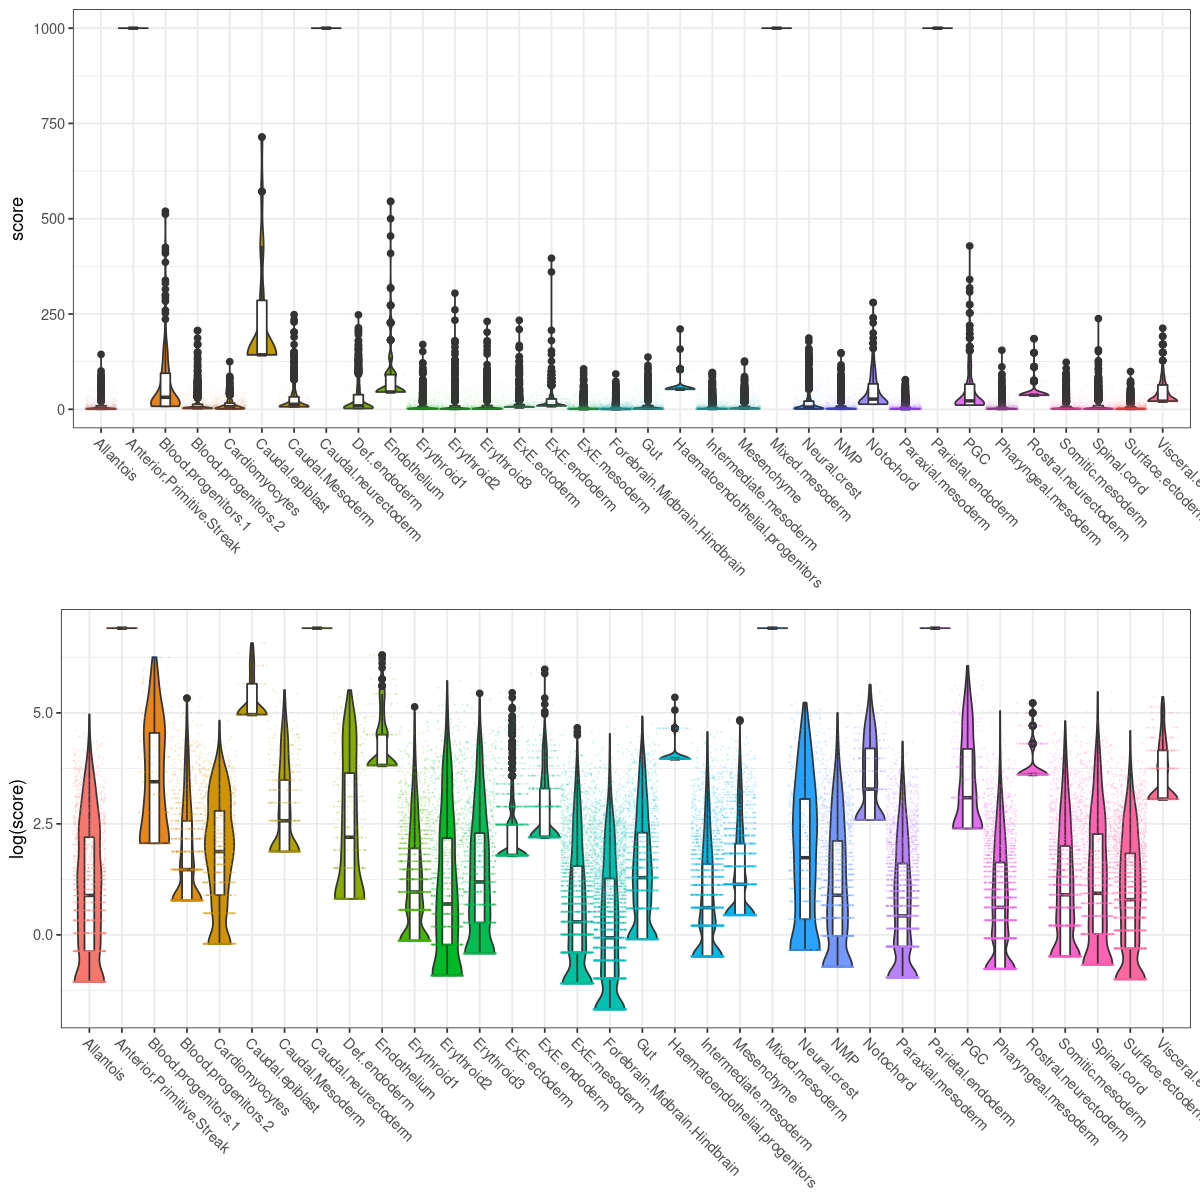

In [58]:
options(repr.plot.width=10, repr.plot.height=10)
grid.arrange(plots = p1,p2, ncol = 1)


png(paste0(plot_folder, "distances_quantified.png"), height=600, width=1000)
    grid.arrange(plots = p1,p2, ncol = 1)
dev.off()

### Without cell number normalisation

In [59]:
distances = read.csv(paste0(in_folder, 'atlas_chim_distances_no_normalisation.csv'))

In [76]:
dist_long = distances[,grep("^adjacency_score_", colnames(distances))] %>% 
                gather(celltype, score) %>%
                filter(score > 0)
dist_long$celltype = str_replace(dist_long$celltype, 'adjacency_score_', '')
dist_long$celltype = str_replace(dist_long$celltype, '\\.', ' ')
dist_long$celltype = str_replace(dist_long$celltype, '\\.', ' ')

In [84]:
source("/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/plot_colours.R")
p1 = ggplot(dist_long, aes(celltype, log(score+1), fill=celltype)) + 
        scale_colour_manual(values = celltype_colours, labels = celltype_labels, name = "celltype") +   
        scale_fill_manual(values = celltype_colours, labels = celltype_labels, name = "celltype") + 
        geom_violin(scale = 'width') +
        geom_boxplot(width=0.3, fill="white") +
        theme_bw() +
        labs(y='2log distance score') +
        ggtitle('Distance score per celltype') +
        theme(axis.text.x = element_text(angle = -45, hjust = 0),
            legend.position = "none",
            axis.title.x = element_blank()) 

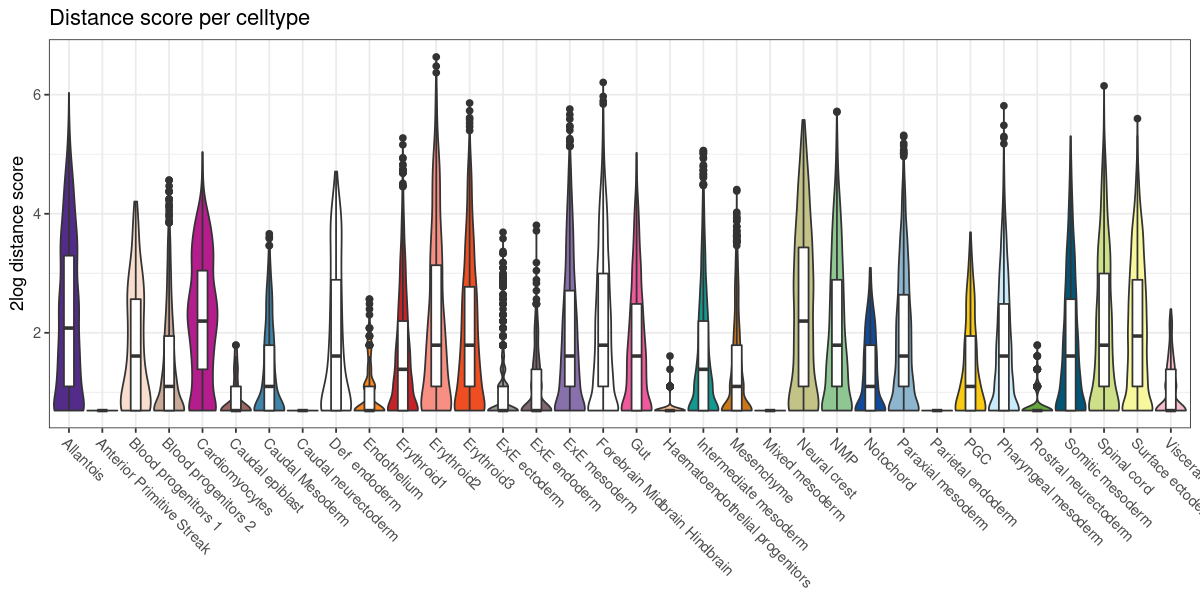

In [85]:
options(repr.plot.width=10, repr.plot.height=5)
p1

In [86]:
pdf(paste0(plot_folder, "distances_quantified_no_normalisation.pdf"), height=6, width=10)
    p1
dev.off()

png 
  2

#### distance chimaera comparing WT vs KO

In [165]:
distances = read.csv(paste0(in_folder, 'chimaera_distances.csv'))

In [166]:
dist_long = distances[,grep("^adjacency_score_", colnames(distances))] %>% 
                gather(celltype, score) %>%
                filter(score > 0)
dist_long$celltype = str_replace(dist_long$celltype, 'adjacency_score_', '')
dist_long$celltype = str_replace(dist_long$celltype, '\\.', ' ')
dist_long$celltype = str_replace(dist_long$celltype, '\\.', ' ')

In [169]:
source("/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/plot_colours.R")
p1 = ggplot(dist_long, aes(celltype, log(score+1), fill=celltype)) + 
        scale_colour_manual(values = celltype_colours, labels = celltype_labels, name = "celltype") +   
        scale_fill_manual(values = celltype_colours, labels = celltype_labels, name = "celltype") + 
        geom_violin(scale = 'width') +
        geom_boxplot(width=0.3, fill="white") +
        theme_bw() +
        labs(y='2log distance score') +
        ggtitle('Distance score per celltype') +
        theme(axis.text.x = element_text(angle = -45, hjust = 0),
            legend.position = "none",
            axis.title.x = element_blank()) 

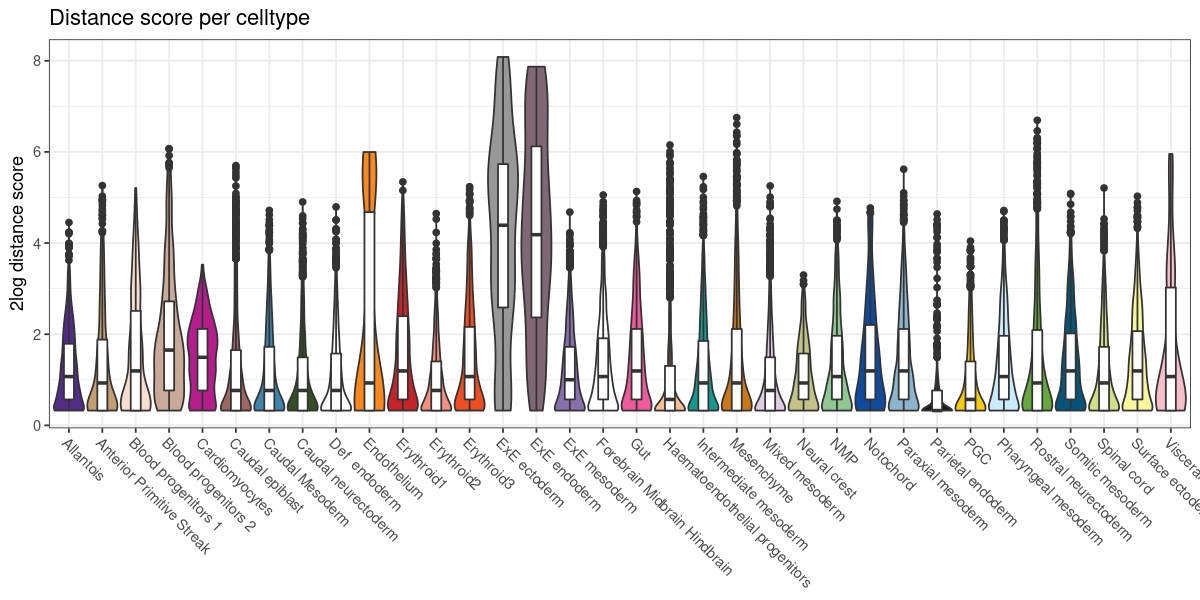

In [170]:
options(repr.plot.width=10, repr.plot.height=5)
p1

In [125]:
dist_long = distances %>% select(grep("^adjacency_score_", colnames(distances)), tdTom) %>% 
                gather(celltype, score, -tdTom) %>%
                filter(score > 0)
dist_long$celltype = str_replace(dist_long$celltype, 'adjacency_score_', '')
dist_long$celltype = str_replace(dist_long$celltype, '\\.', ' ')
dist_long$celltype = str_replace(dist_long$celltype, '\\.', ' ')

In [152]:
p2 = ggplot(dist_long, aes(tdTom, log(score), fill=tdTom)) + 
        geom_violin(scale = 'width', aes(color=celltype), size =1.5) +
        geom_boxplot(width=0.3, fill="white") +
        scale_colour_manual(values = celltype_colours, labels = celltype_labels, name = "celltype") +   
         scale_fill_manual(values = c("pos" = "red", "neg" = "black"), 
                         labels = c("pos" = "Tomato+", "neg" = "Tomato-"),
                         name = "") +
        theme_bw() +
        theme(legend.position = "none",
            axis.title.x = element_blank(),text = element_text(size = 20)) +
        facet_wrap(~celltype) + 
        theme(strip.background = element_blank())

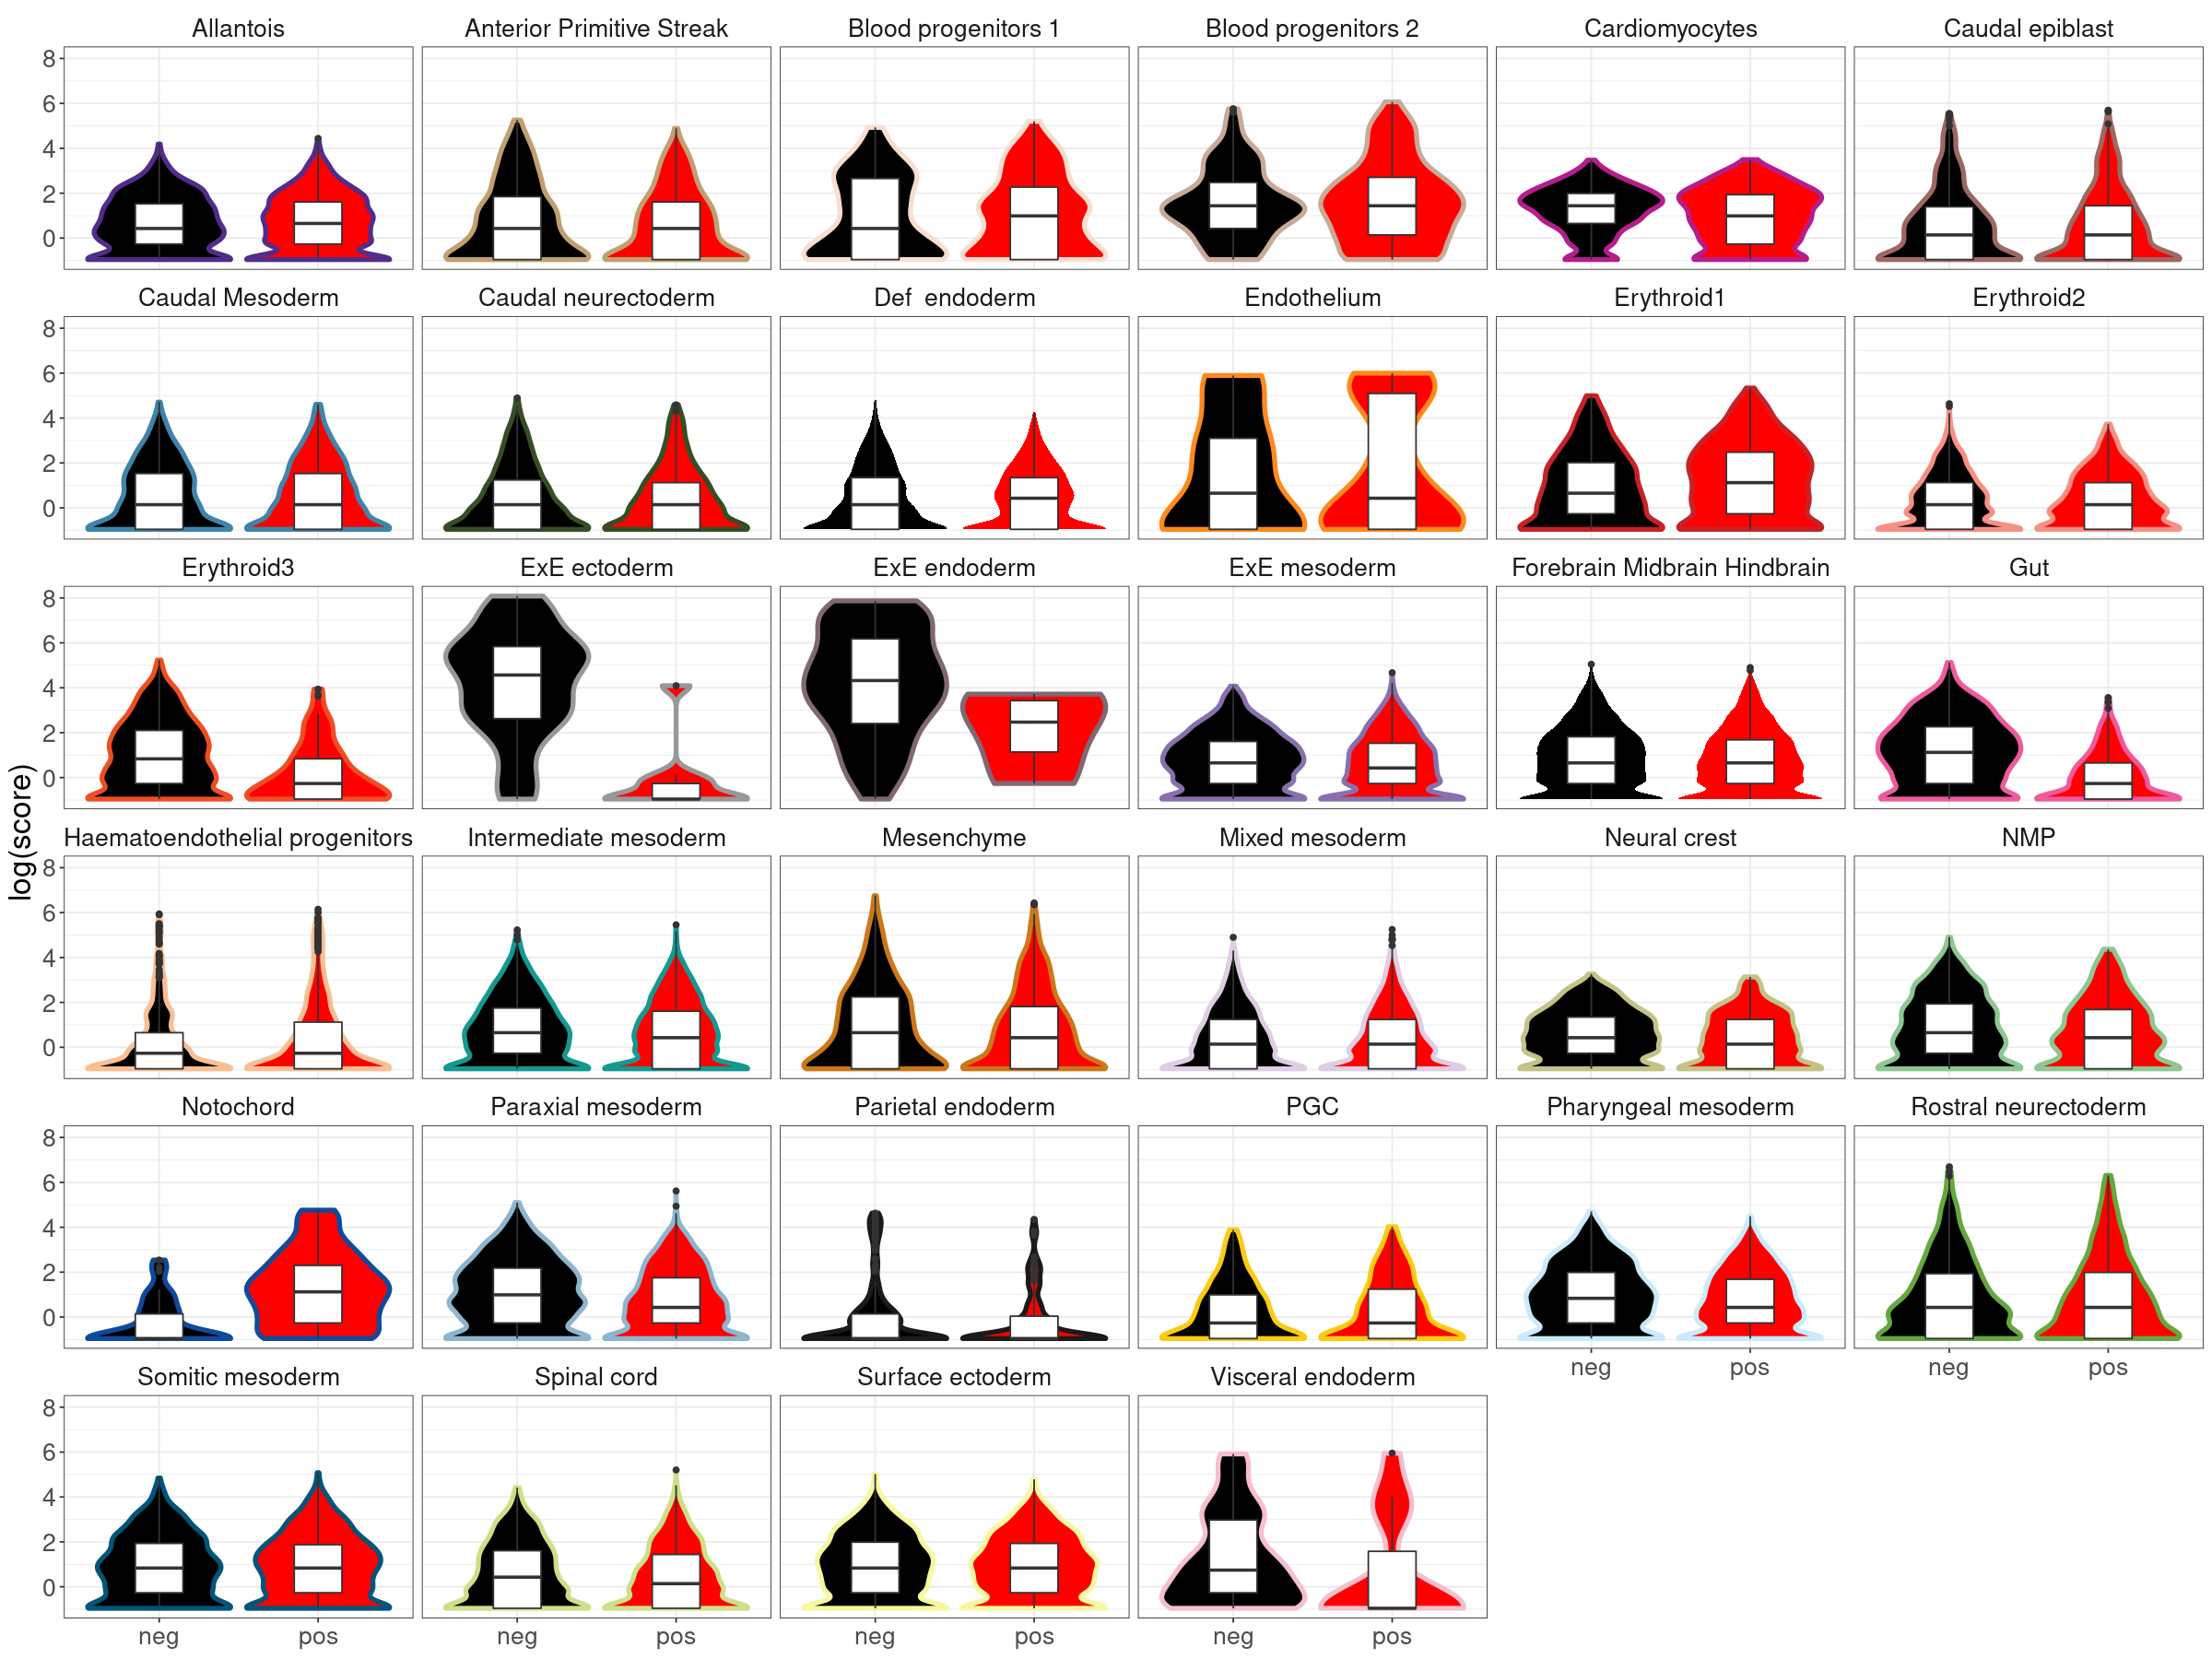

In [153]:
options(repr.plot.width=20, repr.plot.height=15)
p2

#### distance chimaera comparing WT vs KO  - no normalisation

In [22]:
distances = read.csv(paste0(in_folder, 'chimaera_distances_no_normalisation.csv'))

In [4]:
dist_long = distances[,grep("^adjacency_score_", colnames(distances))] %>% 
                gather(celltype, score) %>%
                filter(score > 0)
dist_long$celltype = str_replace(dist_long$celltype, 'adjacency_score_', '')
dist_long$celltype = str_replace(dist_long$celltype, '\\.', ' ')
dist_long$celltype = str_replace(dist_long$celltype, '\\.', ' ')

In [5]:
source("/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/plot_colours.R")
p1 = ggplot(dist_long, aes(celltype, log(score+1), fill=celltype)) + 
        scale_colour_manual(values = celltype_colours, labels = celltype_labels, name = "celltype") +   
        scale_fill_manual(values = celltype_colours, labels = celltype_labels, name = "celltype") + 
        geom_violin(scale = 'width') +
        geom_boxplot(width=0.3, fill="white") +
        theme_bw() +
        labs(y='2log distance score') +
        ggtitle('Distance score per celltype') +
        theme(axis.text.x = element_text(angle = -45, hjust = 0),
            legend.position = "none",
            axis.title.x = element_blank()) 

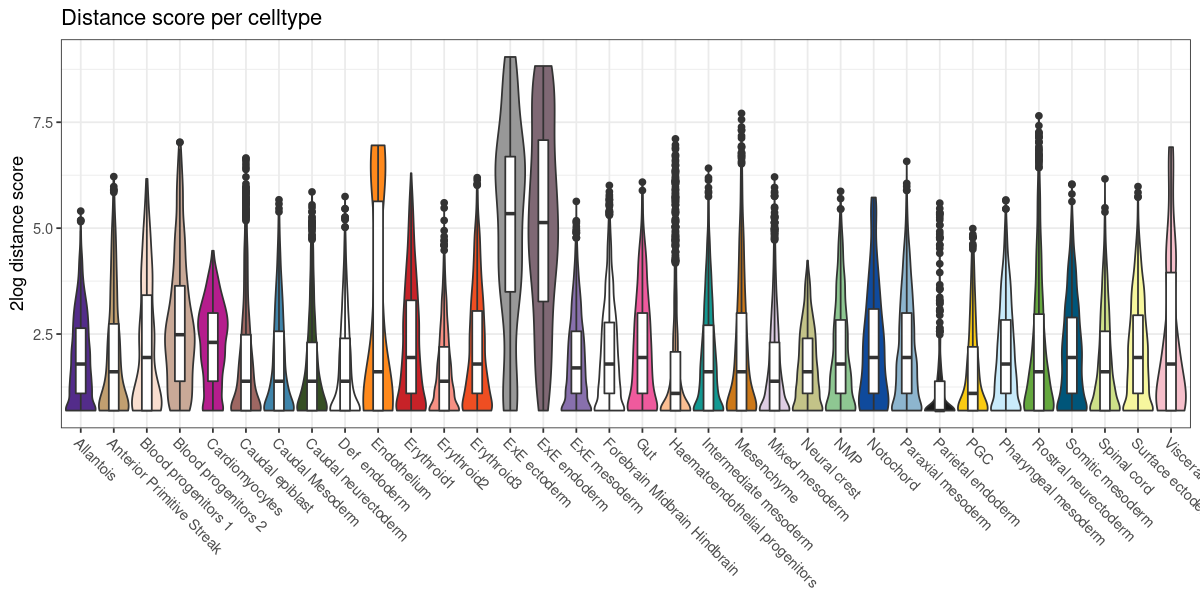

In [6]:
options(repr.plot.width=10, repr.plot.height=5)
p1

In [7]:
pdf(paste0(plot_folder, "chim_distances_quantified_no_normalisation.pdf"), height=6, width=10)
    p1
dev.off()

png 
  2

In [8]:
dist_long = distances %>% select(grep("^adjacency_score_", colnames(distances)), tdTom) %>% 
                gather(celltype, score, -tdTom) %>%
                filter(score > 0)
dist_long$celltype = str_replace(dist_long$celltype, 'adjacency_score_', '')
dist_long$celltype = str_replace(dist_long$celltype, '\\.', ' ')
dist_long$celltype = str_replace(dist_long$celltype, '\\.', ' ')

In [112]:
p2 = ggplot(dist_long, aes(tdTom, log(score), fill=tdTom)) + 
        geom_violin(scale = 'width', aes(color=celltype), size =1.5) +
        geom_boxplot(width=0.3, fill="white") +
        scale_colour_manual(values = celltype_colours, labels = celltype_labels, name = "celltype") +   
         scale_fill_manual(values = c("pos" = "red", "neg" = "black"), 
                         labels = c("pos" = "Tomato+", "neg" = "Tomato-"),
                         name = "") +
        theme_bw() +
        ggtitle('Distance score chimaera') +
        labs(y = 'log distance score') +
        theme(legend.position = "none",
            axis.title.x = element_blank(),text = element_text(size = 20)) +
        facet_wrap(~celltype) + 
        theme(strip.background = element_blank())

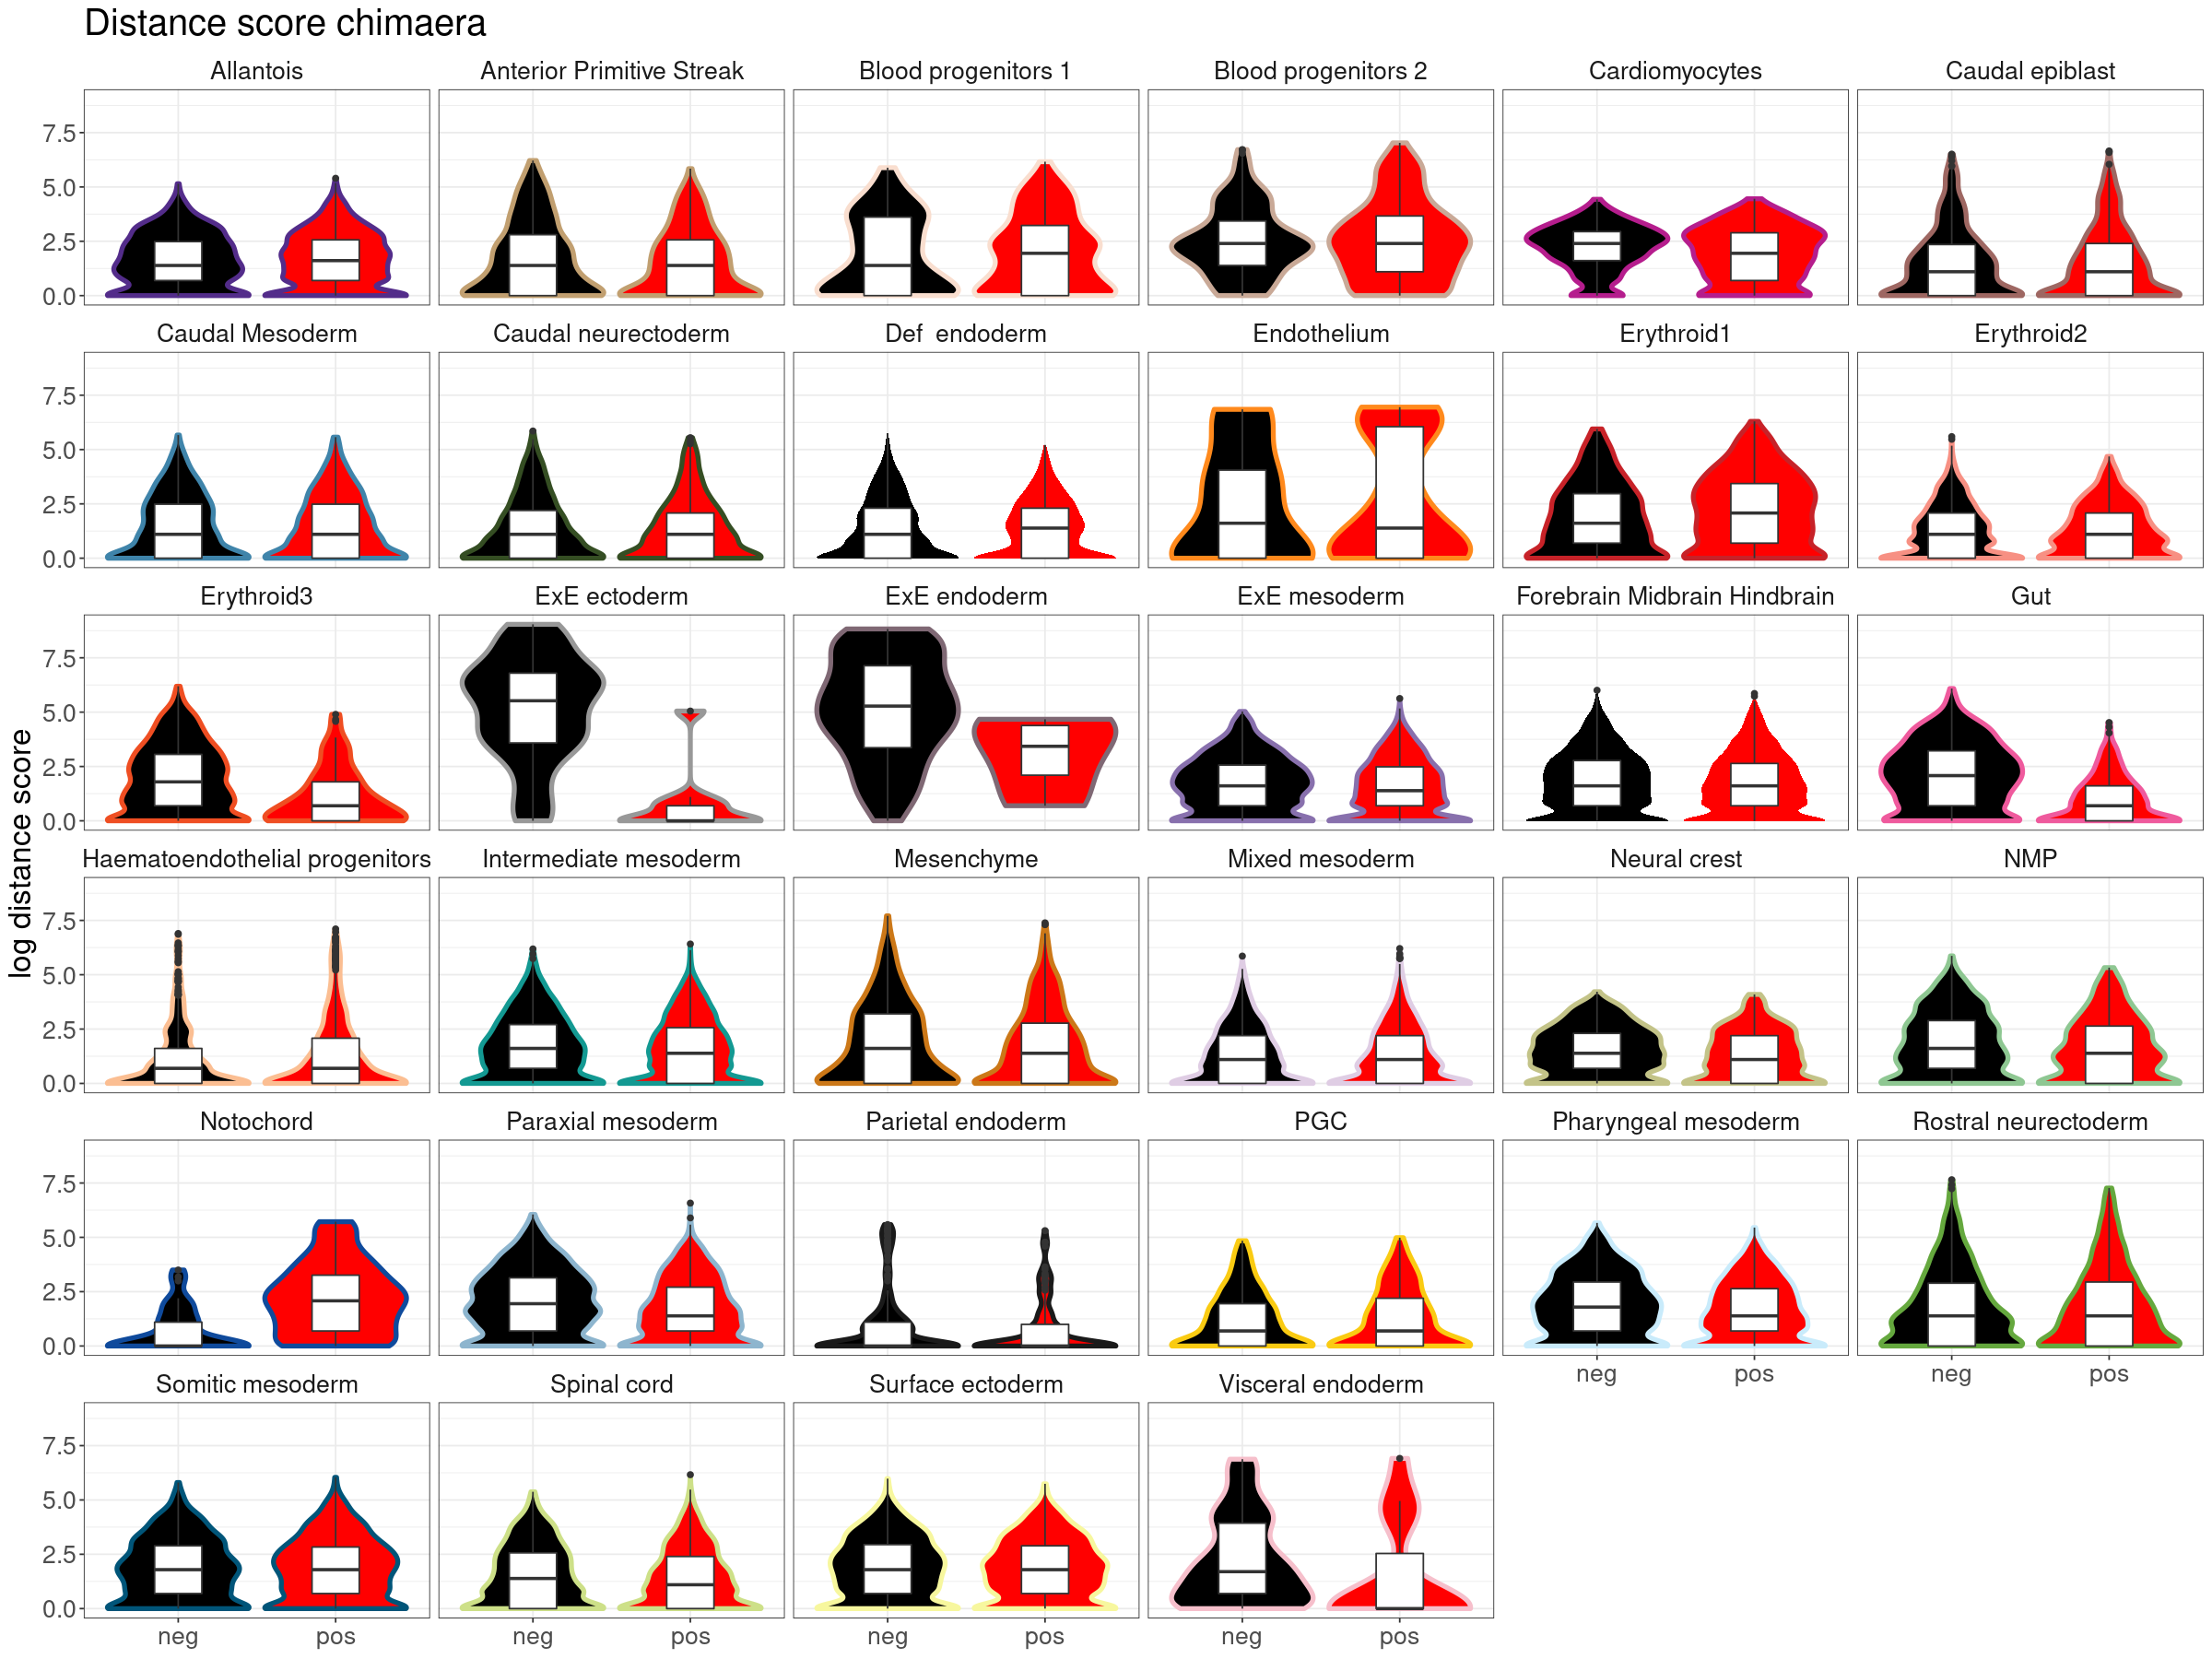

In [113]:
options(repr.plot.width=20, repr.plot.height=15)
p2

In [115]:
pdf(paste0(plot_folder, "chim_distances_wt_ko_comparison.pdf"), height=15, width=15)
    p2
dev.off()

png 
  2

In [137]:
distances$all_distances = rowSums(distances[,grep("^adjacency_score_", colnames(distances))])
distances$log_all_distances = log(distances$all_distances+1)
distances$log_max = log(rowMaxs(as.matrix(distances[,grep("^adjacency_score_", colnames(distances))]))+1)

row_min = distances[,grep("^adjacency_score_", colnames(distances))]
row_min[row_min == 0] = 999
row_min$log_min = log(rowMins(as.matrix(row_min))+1)
row_min[row_min == log(1000)] = 0

distances$log_min = row_min$log_min

In [17]:
umap = read.csv(paste0(in_folder, 'big_umap.csv'))

In [23]:
distances = merge(distances, umap, by='cell', all=TRUE)

In [138]:
library(viridis)
p1 = ggplot(distances, aes(umap_1, umap_2)) + 
    geom_point(aes(color=log_max)) + 
    theme_classic() + 
    scale_color_viridis(option = "D") + 
    theme(axis.line=element_blank(),axis.text.x=element_blank(),
          axis.text.y=element_blank(),axis.ticks=element_blank(),
          axis.title.x=element_blank(),
          axis.title.y=element_blank()) + labs(color = "log distances")

p2 = ggplot(distances, aes(umap_1, umap_2)) + 
    geom_point(aes(color=log_min)) + 
    theme_classic() + 
    scale_color_viridis(option = "D") + 
    theme(axis.line=element_blank(),axis.text.x=element_blank(),
          axis.text.y=element_blank(),axis.ticks=element_blank(),
          axis.title.x=element_blank(),
          axis.title.y=element_blank()) + labs(color = "log distances")

p3 = ggplot(distances, aes(umap_1, umap_2)) + 
    geom_point(aes(color=log_all_distances)) + 
    theme_classic() + 
    scale_color_viridis(option = "D") + 
    theme(axis.line=element_blank(),axis.text.x=element_blank(),
          axis.text.y=element_blank(),axis.ticks=element_blank(),
          axis.title.x=element_blank(),
          axis.title.y=element_blank()) + labs(color = "log distances")

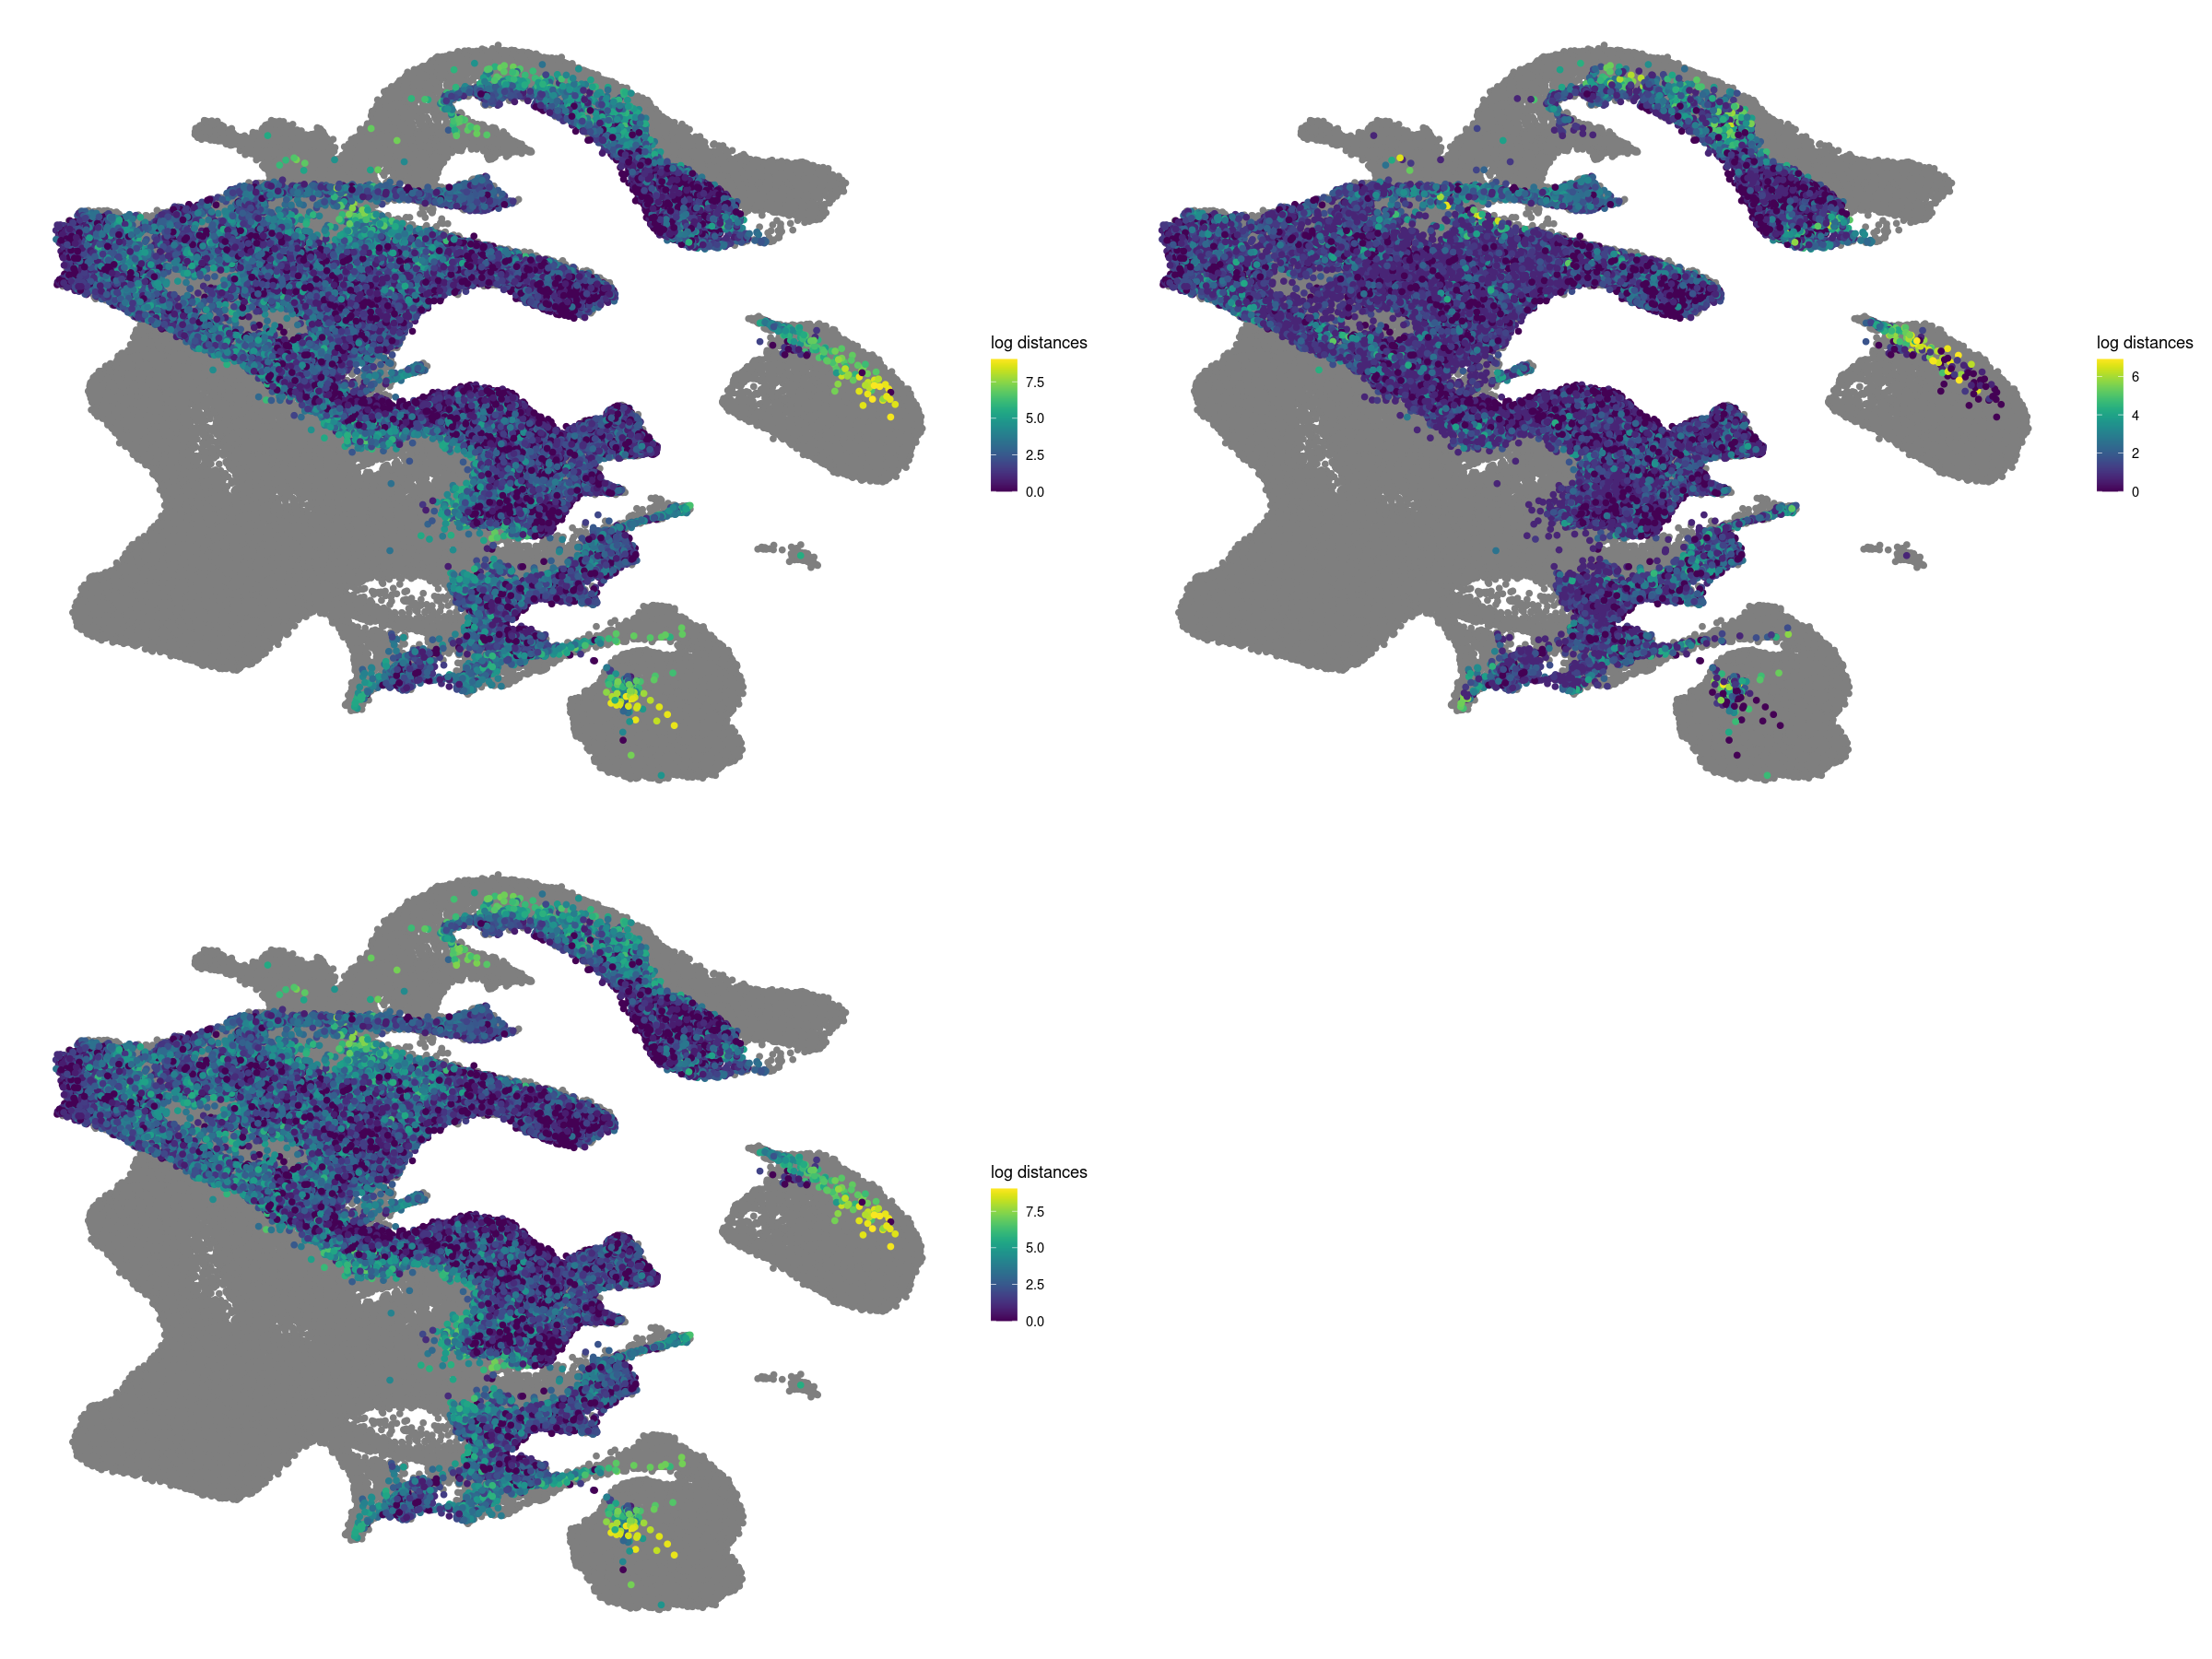

In [139]:
grid.arrange(plots = p1,p2,p3, ncol = 2)

In [142]:
colnames(distances)

[1] "cell"                                          
 [2] "sample"                                        
 [3] "stage"                                         
 [4] "barcode"                                       
 [5] "sequencing.batch"                              
 [6] "stripped"                                      
 [7] "doublet"                                       
 [8] "theiler"                                       
 [9] "doub.density"                                  
[10] "cluster"                                       
[11] "cluster.sub"                                   
[12] "cluster.stage"                                 
[13] "cluster.theiler"                               
[14] "celltype"                                      
[15] "colour"                                        
[16] "umapX"                                         
[17] "umapY"                                         
[18] "haem_gephiX"                                   
[19] "haem_gephiY"                                   
[20] "haem_subclust"                                 
[21] "endo_gephiX"                                   
[22] "endo_gephiY"                                   
[23] "endo_trajectoryName"                           
[24] "endo_trajectoryDPT"                            
[25] "endo_gutX"                                     
[26] "endo_gutY"                                     
[27] "endo_gutDPT"                                   
[28] "endo_gutCluster"                               
[29] "weight"                                        
[30] "stage.mapped"                                  
[31] "celltype.mapped"                               
[32] "closest.cell"                                  
[33] "sizeFactor"                                    
[34] "tdTom"                                         
[35] "origin"                                        
[36] "adjacency_score_Paraxial.mesoderm"             
[37] "adjacency_score_Erythroid3"                    
[38] "adjacency_score_Pharyngeal.mesoderm"           
[39] "adjacency_score_Forebrain.Midbrain.Hindbrain"  
[40] "adjacency_score_NMP"                           
[41] "adjacency_score_Erythroid2"                    
[42] "adjacency_score_Surface.ectoderm"              
[43] "adjacency_score_ExE.mesoderm"                  
[44] "adjacency_score_Cardiomyocytes"                
[45] "adjacency_score_Gut"                           
[46] "adjacency_score_Somitic.mesoderm"              
[47] "adjacency_score_Neural.crest"                  
[48] "adjacency_score_Erythroid1"                    
[49] "adjacency_score_Spinal.cord"                   
[50] "adjacency_score_PGC"                           
[51] "adjacency_score_Intermediate.mesoderm"         
[52] "adjacency_score_Caudal.Mesoderm"               
[53] "adjacency_score_Blood.progenitors.2"           
[54] "adjacency_score_ExE.endoderm"                  
[55] "adjacency_score_Allantois"                     
[56] "adjacency_score_Blood.progenitors.1"           
[57] "adjacency_score_Def..endoderm"                 
[58] "adjacency_score_ExE.ectoderm"                  
[59] "adjacency_score_Mesenchyme"                    
[60] "adjacency_score_Notochord"                     
[61] "adjacency_score_Caudal.neurectoderm"           
[62] "adjacency_score_Visceral.endoderm"             
[63] "adjacency_score_Endothelium"                   
[64] "adjacency_score_Rostral.neurectoderm"          
[65] "adjacency_score_Haematoendothelial.progenitors"
[66] "adjacency_score_Mixed.mesoderm"                
[67] "adjacency_score_Caudal.epiblast"               
[68] "adjacency_score_Parietal.endoderm"             
[69] "adjacency_score_Anterior.Primitive.Streak"     
[70] "umap_1"                                        
[71] "umap_2"                                        
[72] "all_distances"                                 
[73] "log_all_distances"                             
[74] "log_max"                                       
[75] 

In [ ]:
dist_long = distances %>% select(grep("^adjacency_score_", colnames(distances)), tdTom) %>% 
                gather(celltype, score, -tdTom) %>%
                filter(score > 0)
dist_long$celltype = str_replace(dist_long$celltype, 'adjacency_score_', '')
dist_long$celltype = str_replace(dist_long$celltype, '\\.', ' ')
dist_long$celltype = str_replace(dist_long$celltype, '\\.', ' ')

Warning message:
“Computation failed in `stat_ydensity()`:
replacement has 1 row, data has 0”
Warning message:
“Computation failed in `stat_ydensity()`:
replacement has 1 row, data has 0”
Warning message:
“Computation failed in `stat_ydensity()`:
replacement has 1 row, data has 0”
Warning message:
“Computation failed in `stat_ydensity()`:
replacement has 1 row, data has 0”


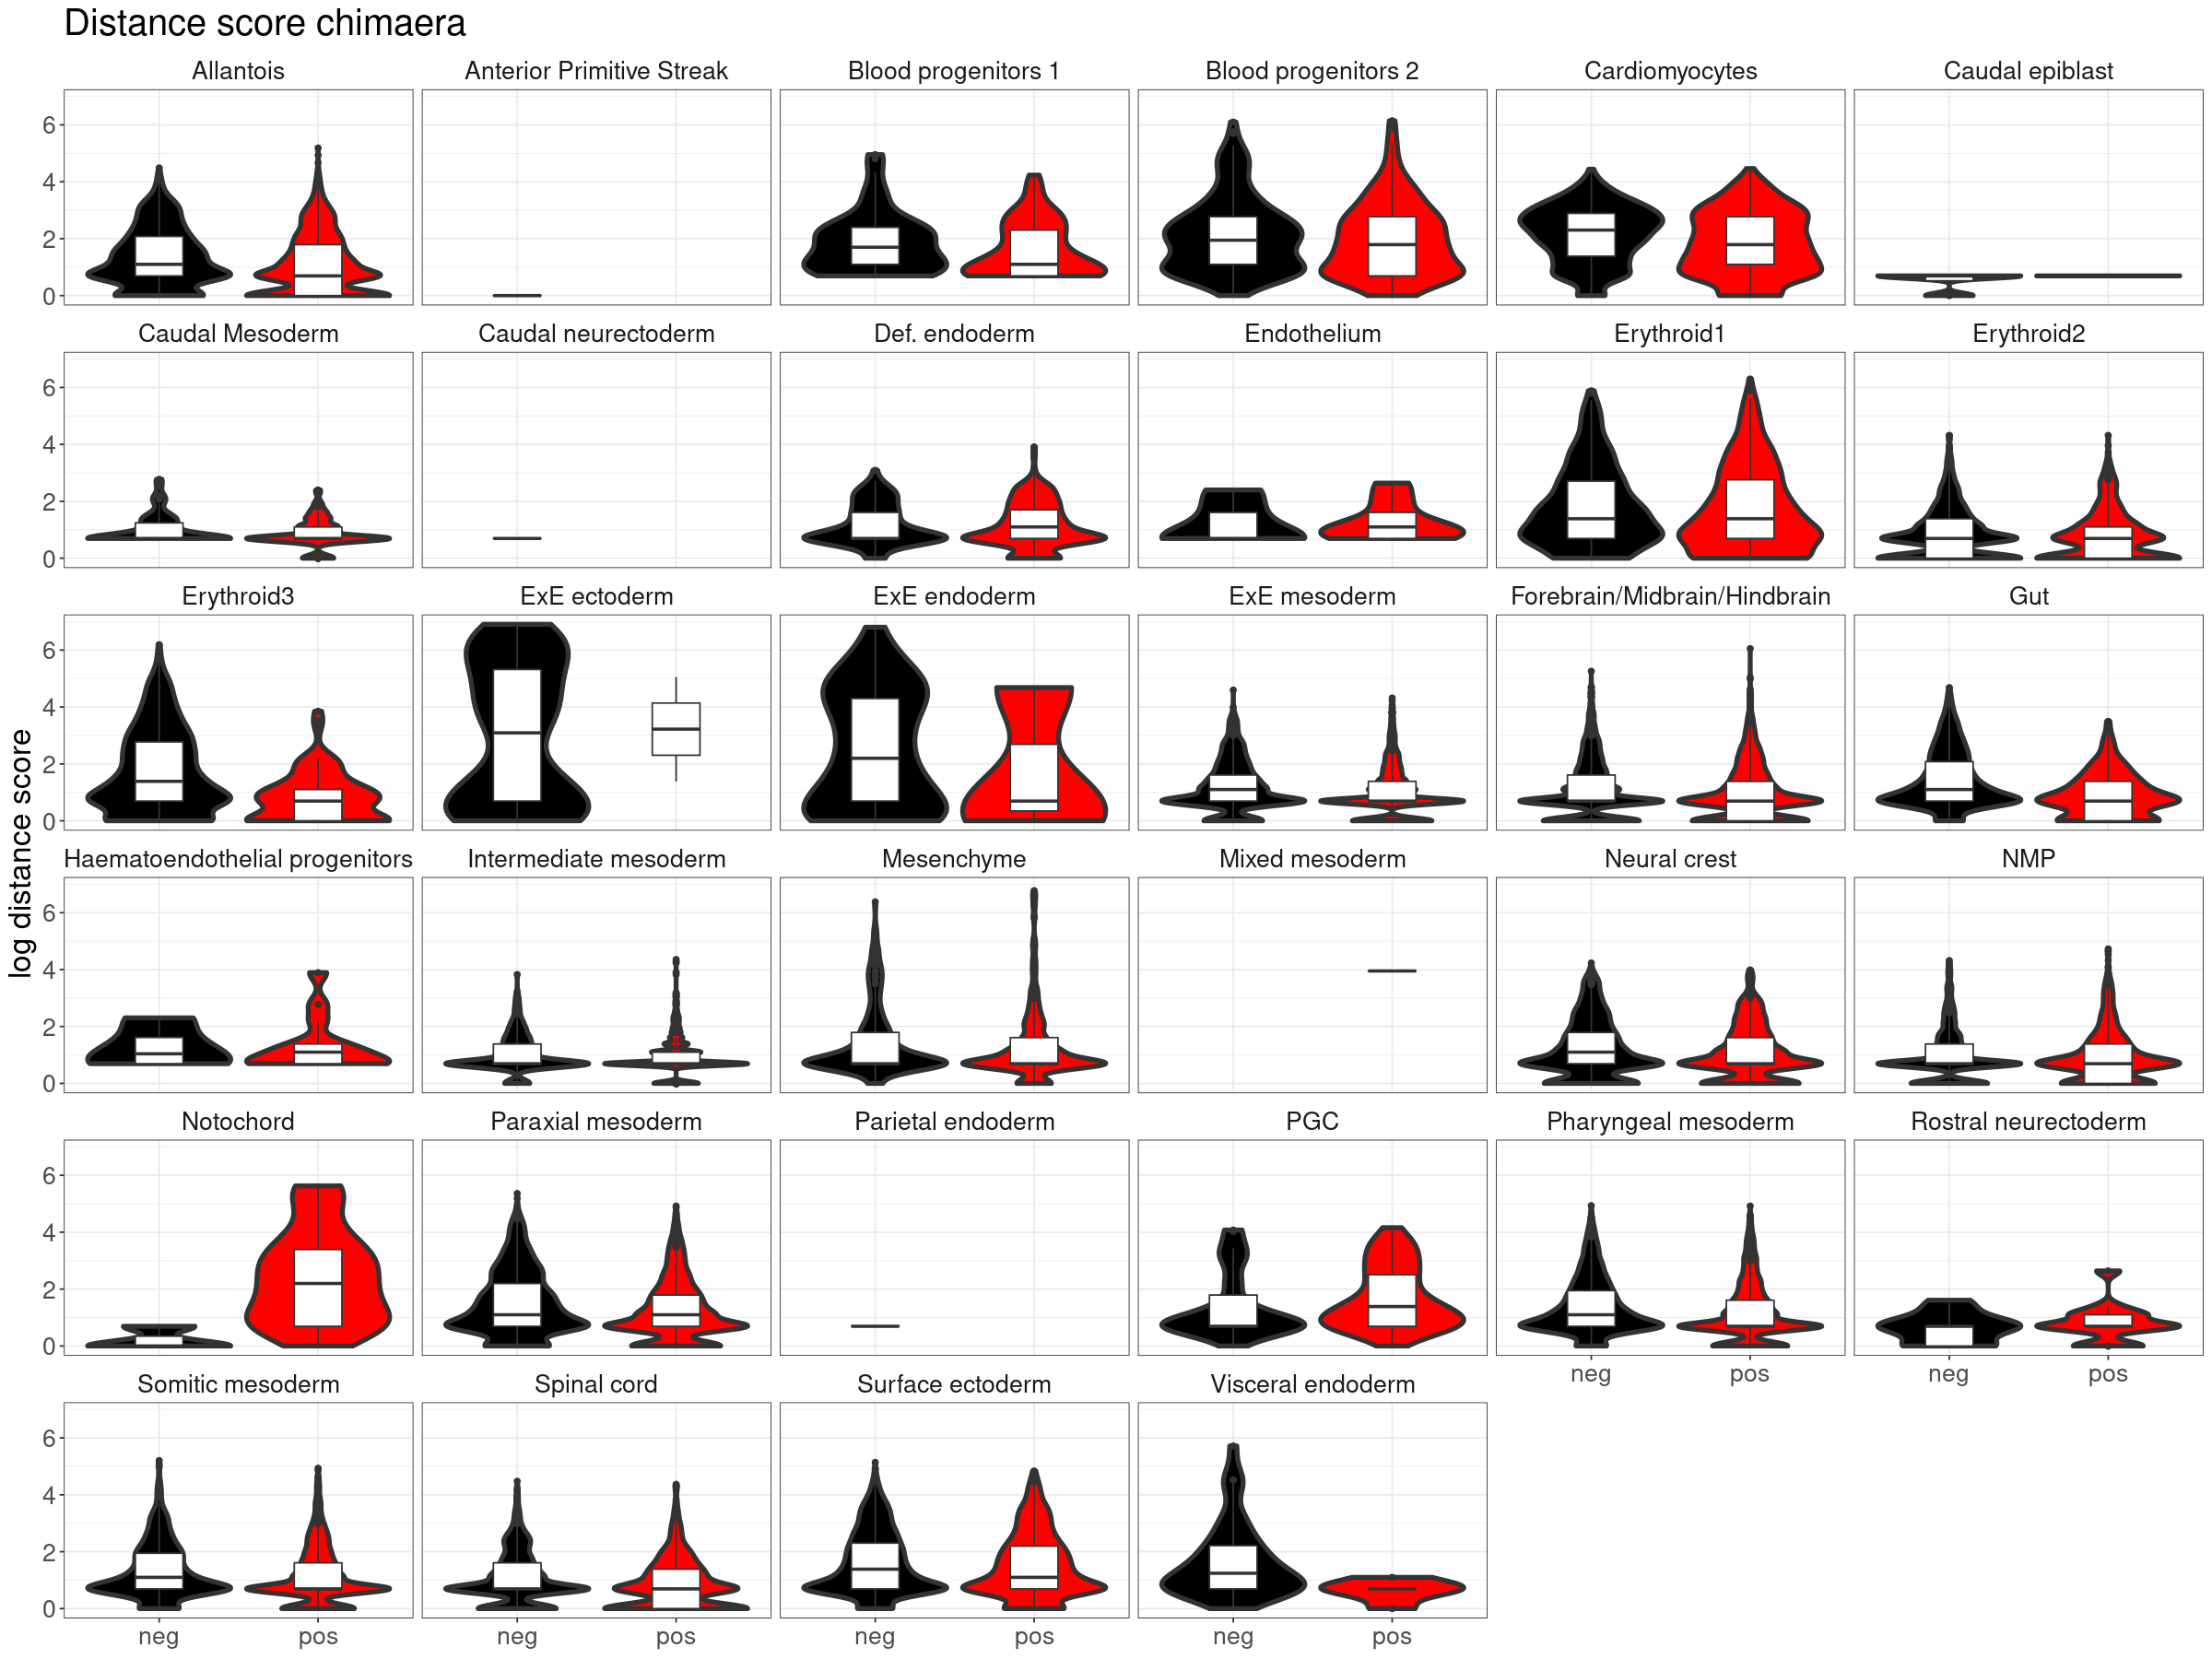

In [150]:
chim = distances %>% filter(tdTom != 'NA')
ggplot(chim, aes(tdTom, log_min, fill=tdTom)) + 
        geom_violin(scale = 'width', size =1.5) +
        geom_boxplot(width=0.3, fill="white") +
        scale_colour_manual(values = celltype_colours, labels = celltype_labels, name = "celltype") +   
         scale_fill_manual(values = c("pos" = "red", "neg" = "black"), 
                         labels = c("pos" = "Tomato+", "neg" = "Tomato-"),
                         name = "") +
        theme_bw() +
        ggtitle('Distance score chimaera') +
        labs(y = 'log distance score') +
        theme(legend.position = "none",
            axis.title.x = element_blank(),text = element_text(size = 20)) +
        facet_wrap(~celltype) + 
        theme(strip.background = element_blank())

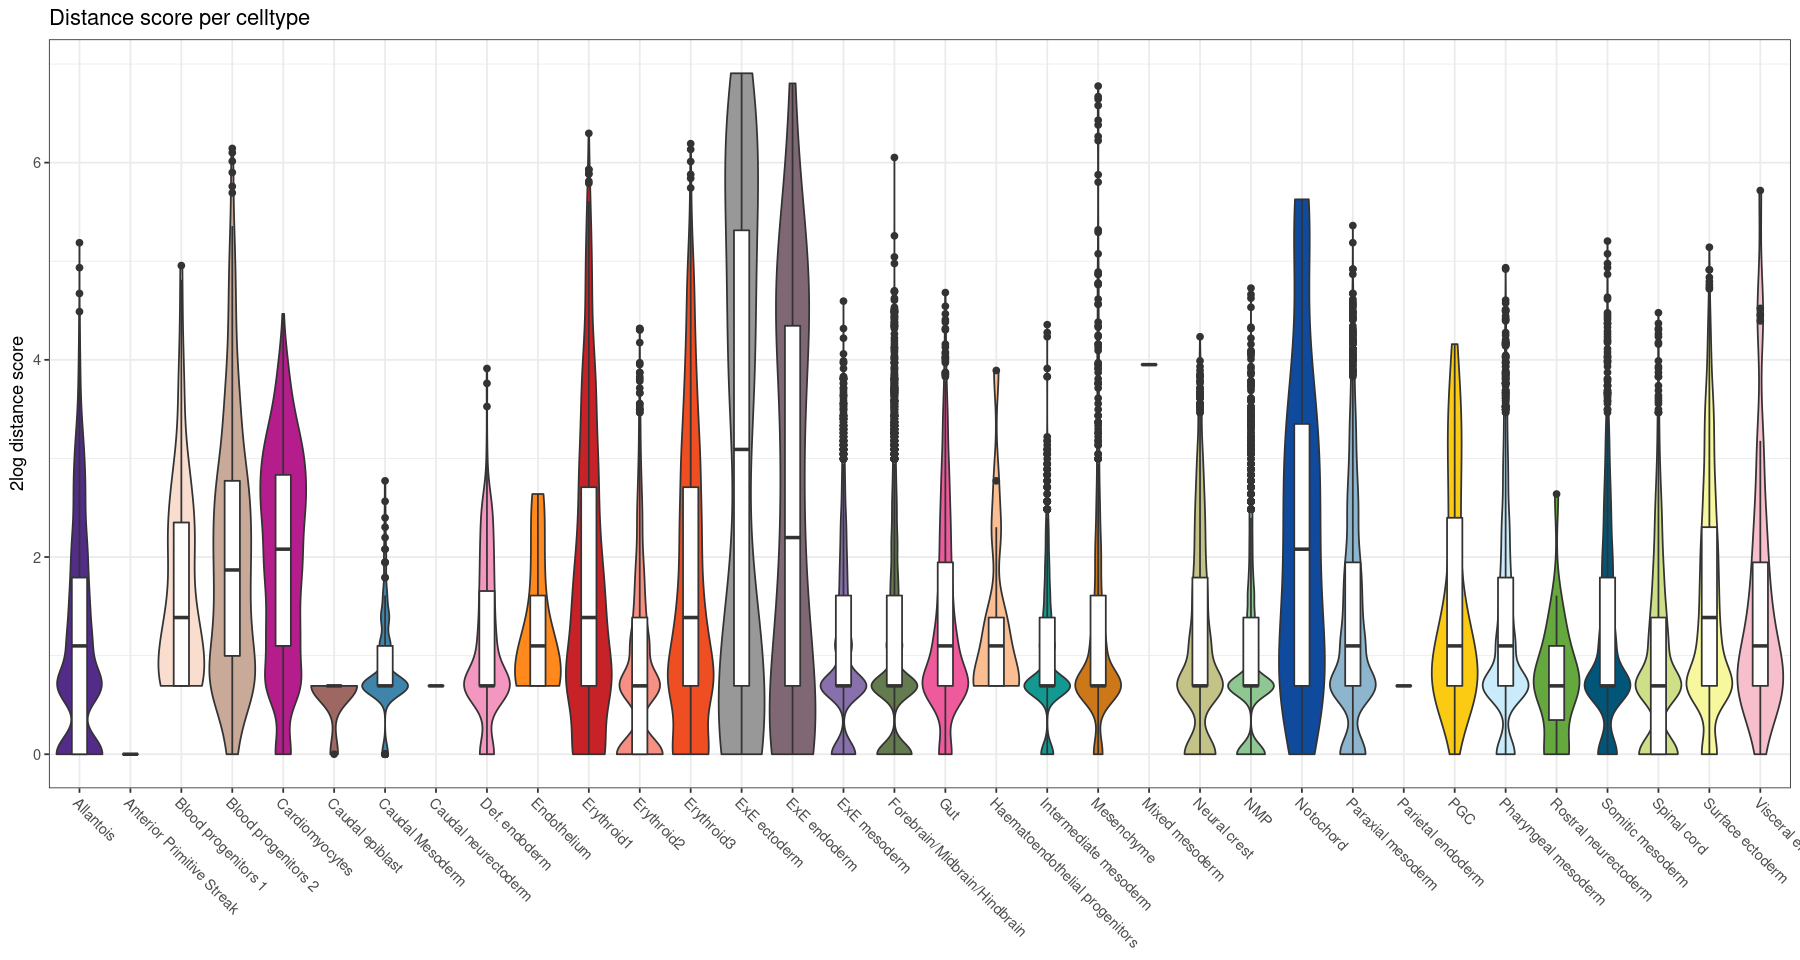

In [175]:
options(repr.plot.width=15, repr.plot.height=8)
ggplot(chim, aes(celltype, log_min, fill=celltype)) + 
        scale_colour_manual(values = celltype_colours, labels = celltype_labels, name = "celltype") +   
        scale_fill_manual(values = celltype_colours, labels = celltype_labels, name = "celltype") + 
        geom_violin(scale = 'width') +
        geom_boxplot(width=0.3, fill="white") +
        theme_bw() +
        labs(y='2log distance score') +
        ggtitle('Distance score per celltype') +
        theme(axis.text.x = element_text(angle = -45, hjust = 0),
            legend.position = "none",
            axis.title.x = element_blank()) 

### Final distance scores!!

In [3]:
distances = read.csv(paste0(in_folder, 'chimaera_distances_complete.csv'))

In [27]:
tail(distances)

,cell,sample,stage,barcode,sequencing.batch,stripped,doublet,theiler,doub.density,cluster,⋯,endo_gutDPT,endo_gutCluster,weight,stage.mapped,celltype.mapped,closest.cell,sizeFactor,tdTom,origin,adjacency_score_chim
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<dbl>,<lgl>,<lgl>,⋯,<lgl>,<dbl>,<int>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>
37203,chim_cell_43818,mixl_6,E8.5,TTTGGTTTCCCTATTA,1,False,False,NaN,NA,NA,⋯,NA,NaN,183149,E8.0,ExE mesoderm,atlas_cell_130256,1.1753578,pos,chimaera,2
37204,chim_cell_43819,mixl_6,E8.5,TTTGGTTTCGGACCAC,1,False,False,NaN,NA,NA,⋯,NA,NaN,183150,E8.0,Intermediate mesoderm,atlas_cell_121130,1.0294517,pos,chimaera,61
37205,chim_cell_43821,mixl_6,E8.5,TTTGTTGGTCACTTAG,1,False,False,NaN,NA,NA,⋯,NA,NaN,183152,E8.25,Paraxial mesoderm,atlas_cell_63302,1.9021550,pos,chimaera,7
37206,chim_cell_43822,mixl_6,E8.5,TTTGTTGGTCCGACGT,1,False,False,NaN,NA,NA,⋯,NA,NaN,183153,E8.5,Neural crest,atlas_cell_102526,0.8390008,pos,chimaera,0
37207,chim_cell_43824,mixl_6,E8.5,TTTGTTGTCCACCCTA,1,False,False,NaN,NA,NA,⋯,NA,NaN,183155,E8.5,Allantois,atlas_cell_67426,1.6962690,pos,chimaera,0
37208,chim_cell_43825,mixl_6,E8.5,TTTGTTGTCGCCAGAC,1,False,False,NaN,NA,NA,⋯,NA,NaN,183156,E8.25,ExE mesoderm,atlas_cell_130861,1.1015143,pos,chimaera,12


In [5]:
source("/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/plot_colours.R")
chim = distances %>% filter(tdTom != 'NA')
p1 = ggplot(chim, aes(celltype, log(adjacency_score_chim+1), fill=celltype)) + 
        scale_colour_manual(values = celltype_colours, labels = celltype_labels, name = "celltype") +   
        scale_fill_manual(values = celltype_colours, labels = celltype_labels, name = "celltype") + 
        geom_violin(scale = 'width') +
        geom_boxplot(width=0.3, fill="white") +
        theme_bw() +
        labs(y='2log distance score') +
        ggtitle('Distance score per celltype') +
        theme(axis.text.x = element_text(angle = -45, hjust = 0, size = 10),
            legend.position = "none",
            axis.title.x = element_blank()) 

png 
  2

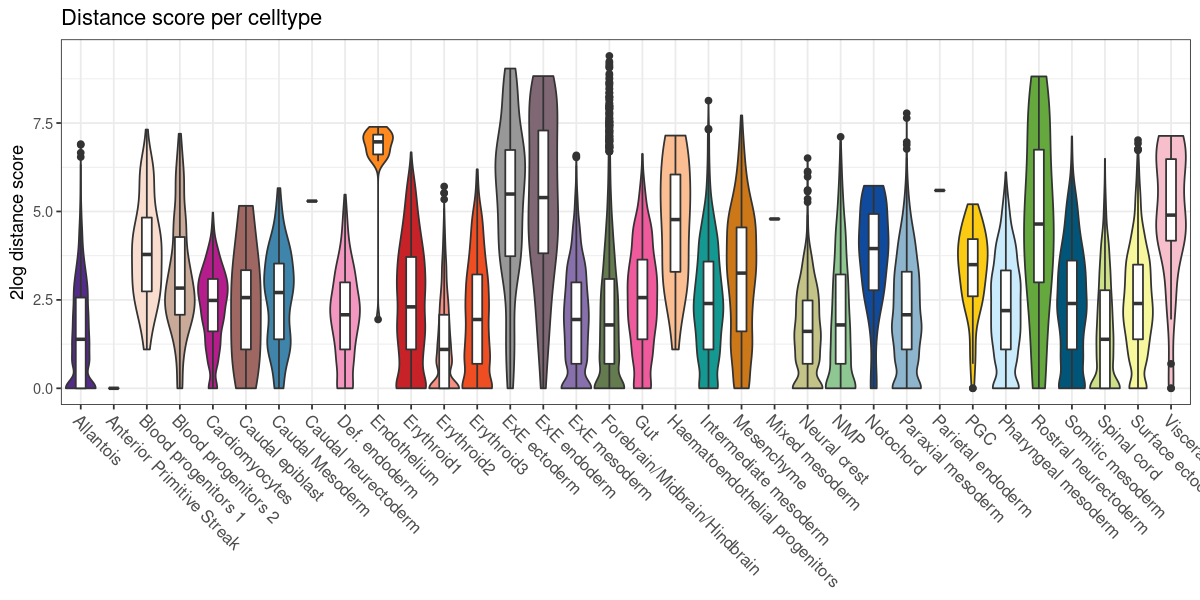

In [6]:
options(repr.plot.width=10, repr.plot.height=5)
p1
pdf(paste0(plot_folder, "chim_distances_complete.pdf"), height=4, width=6)
    p1
dev.off()

In [135]:
test2 = merge(chim, test, by=c('celltype', 'tdTom'))
test2$count <- as.character(test2$count)

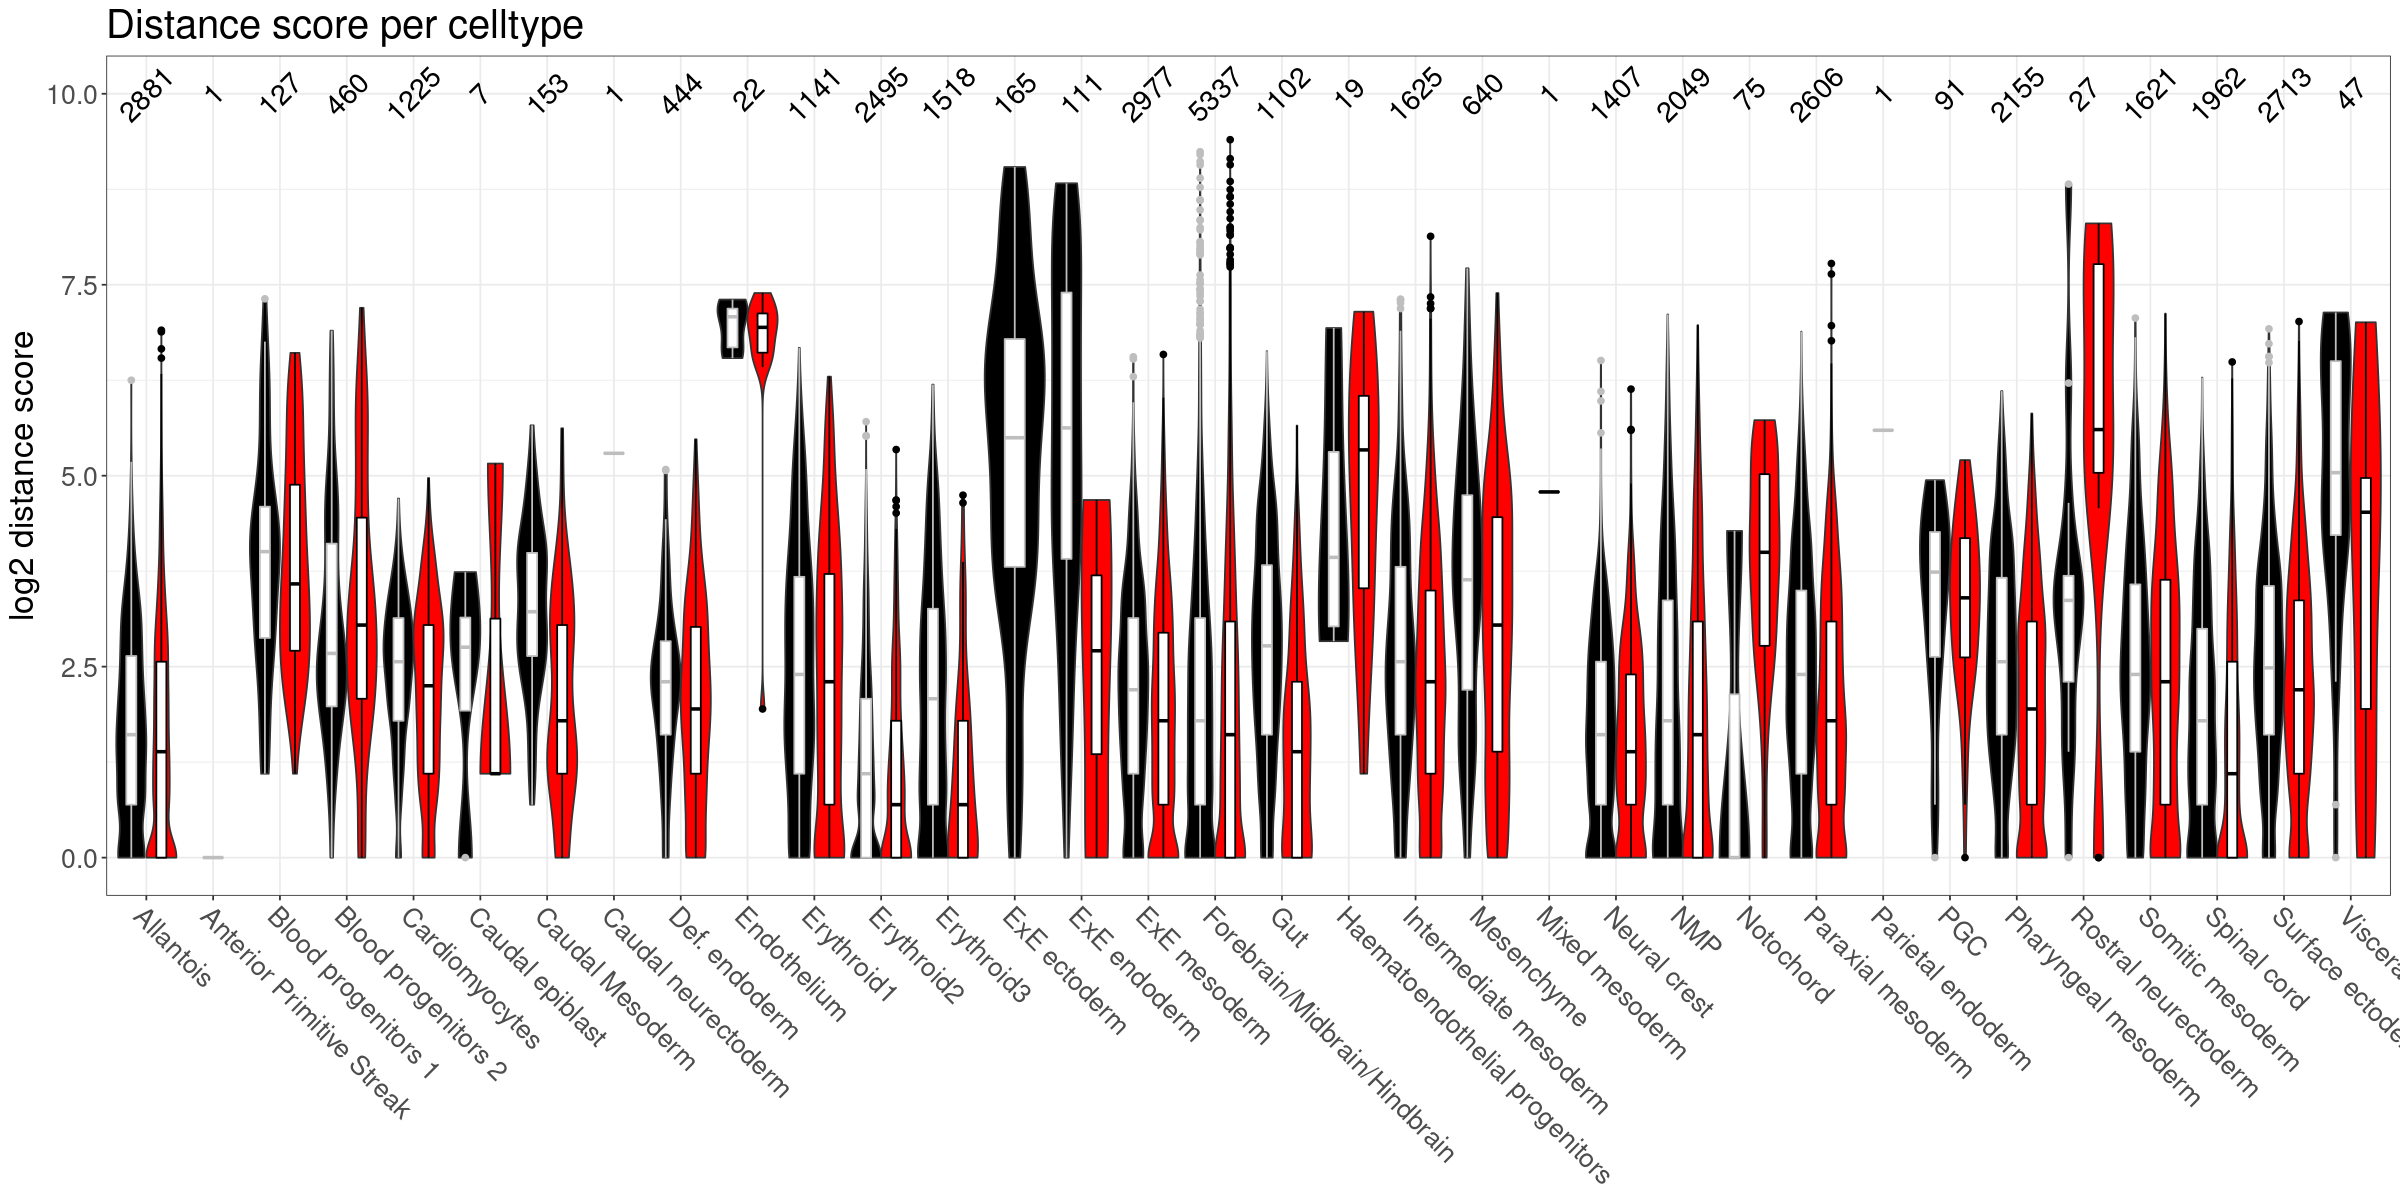

In [142]:
source("/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/plot_colours.R")

exclude = distances %>% filter(celltype=='ExE ectoderm' & tdTom=='pos') %>% .$cell # exclude these 2 cells bc mess up violin

chim = distances %>% filter(tdTom != 'NA' & !cell %in% exclude )
p1 = ggplot(chim, aes(celltype, log(adjacency_score_chim+1), fill=tdTom)) +
        scale_colour_manual(values = c("pos" = "black", "neg" = "grey")) +   
         scale_fill_manual(values = c("pos" = "red", "neg" = "black"), 
                         labels = c("pos" = "Tomato+", "neg" = "Tomato-"),
                         name = "") +
        geom_violin(scale = 'width') +
        geom_boxplot(data=chim, aes(color=tdTom), width=0.3, position=position_dodge(0.9), fill='white') +
        theme_bw() +
        labs(y='log2 distance score') +
        ggtitle('Distance score per celltype') +
        ylim(0, 10) + 
        geom_text(aes(celltype, label=..count.., group=celltype), y=10, stat='count', size=6, angle=45) +
        theme(axis.text.x = element_text(angle = -45, hjust = 0),
            legend.position = "none", text = element_text(size = 20),
            axis.title.x = element_blank()) 

options(repr.plot.width=20, repr.plot.height=10)
p1

png 
  2

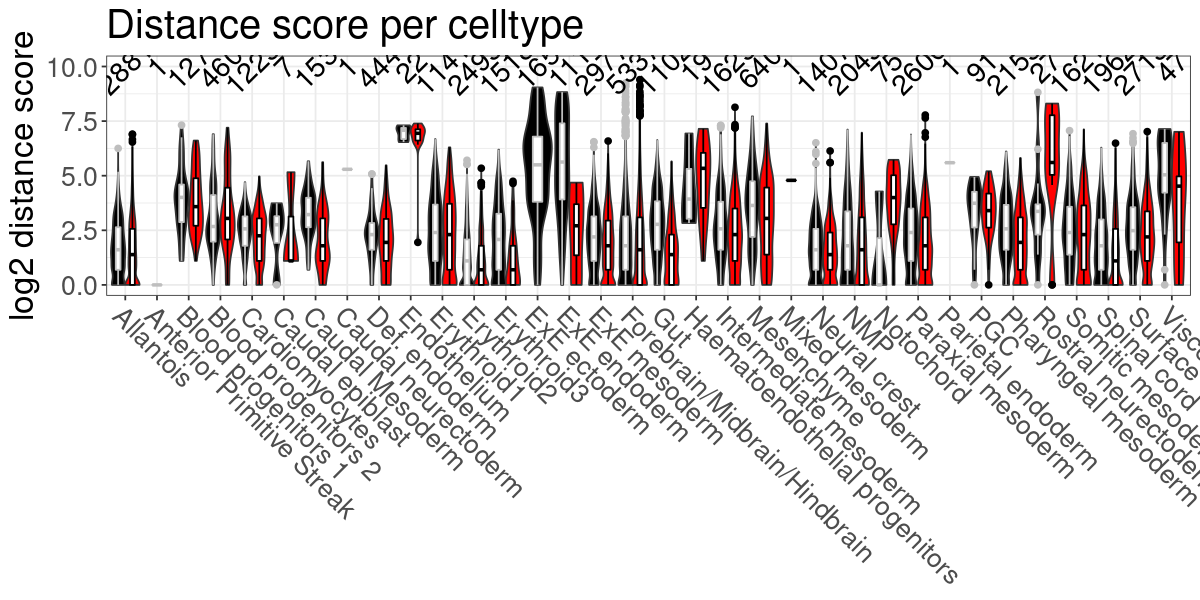

In [113]:
options(repr.plot.width=10, repr.plot.height=5)
p1
pdf(paste0(plot_folder, "chim_distances_complete_tdtom.pdf"), height=8, width=15)
    p1
dev.off()

Warning message:
“Computation failed in `stat_ydensity()`:
replacement has 1 row, data has 0”
Warning message:
“Computation failed in `stat_ydensity()`:
replacement has 1 row, data has 0”
Warning message:
“Computation failed in `stat_ydensity()`:
replacement has 1 row, data has 0”
Warning message:
“Computation failed in `stat_ydensity()`:
replacement has 1 row, data has 0”


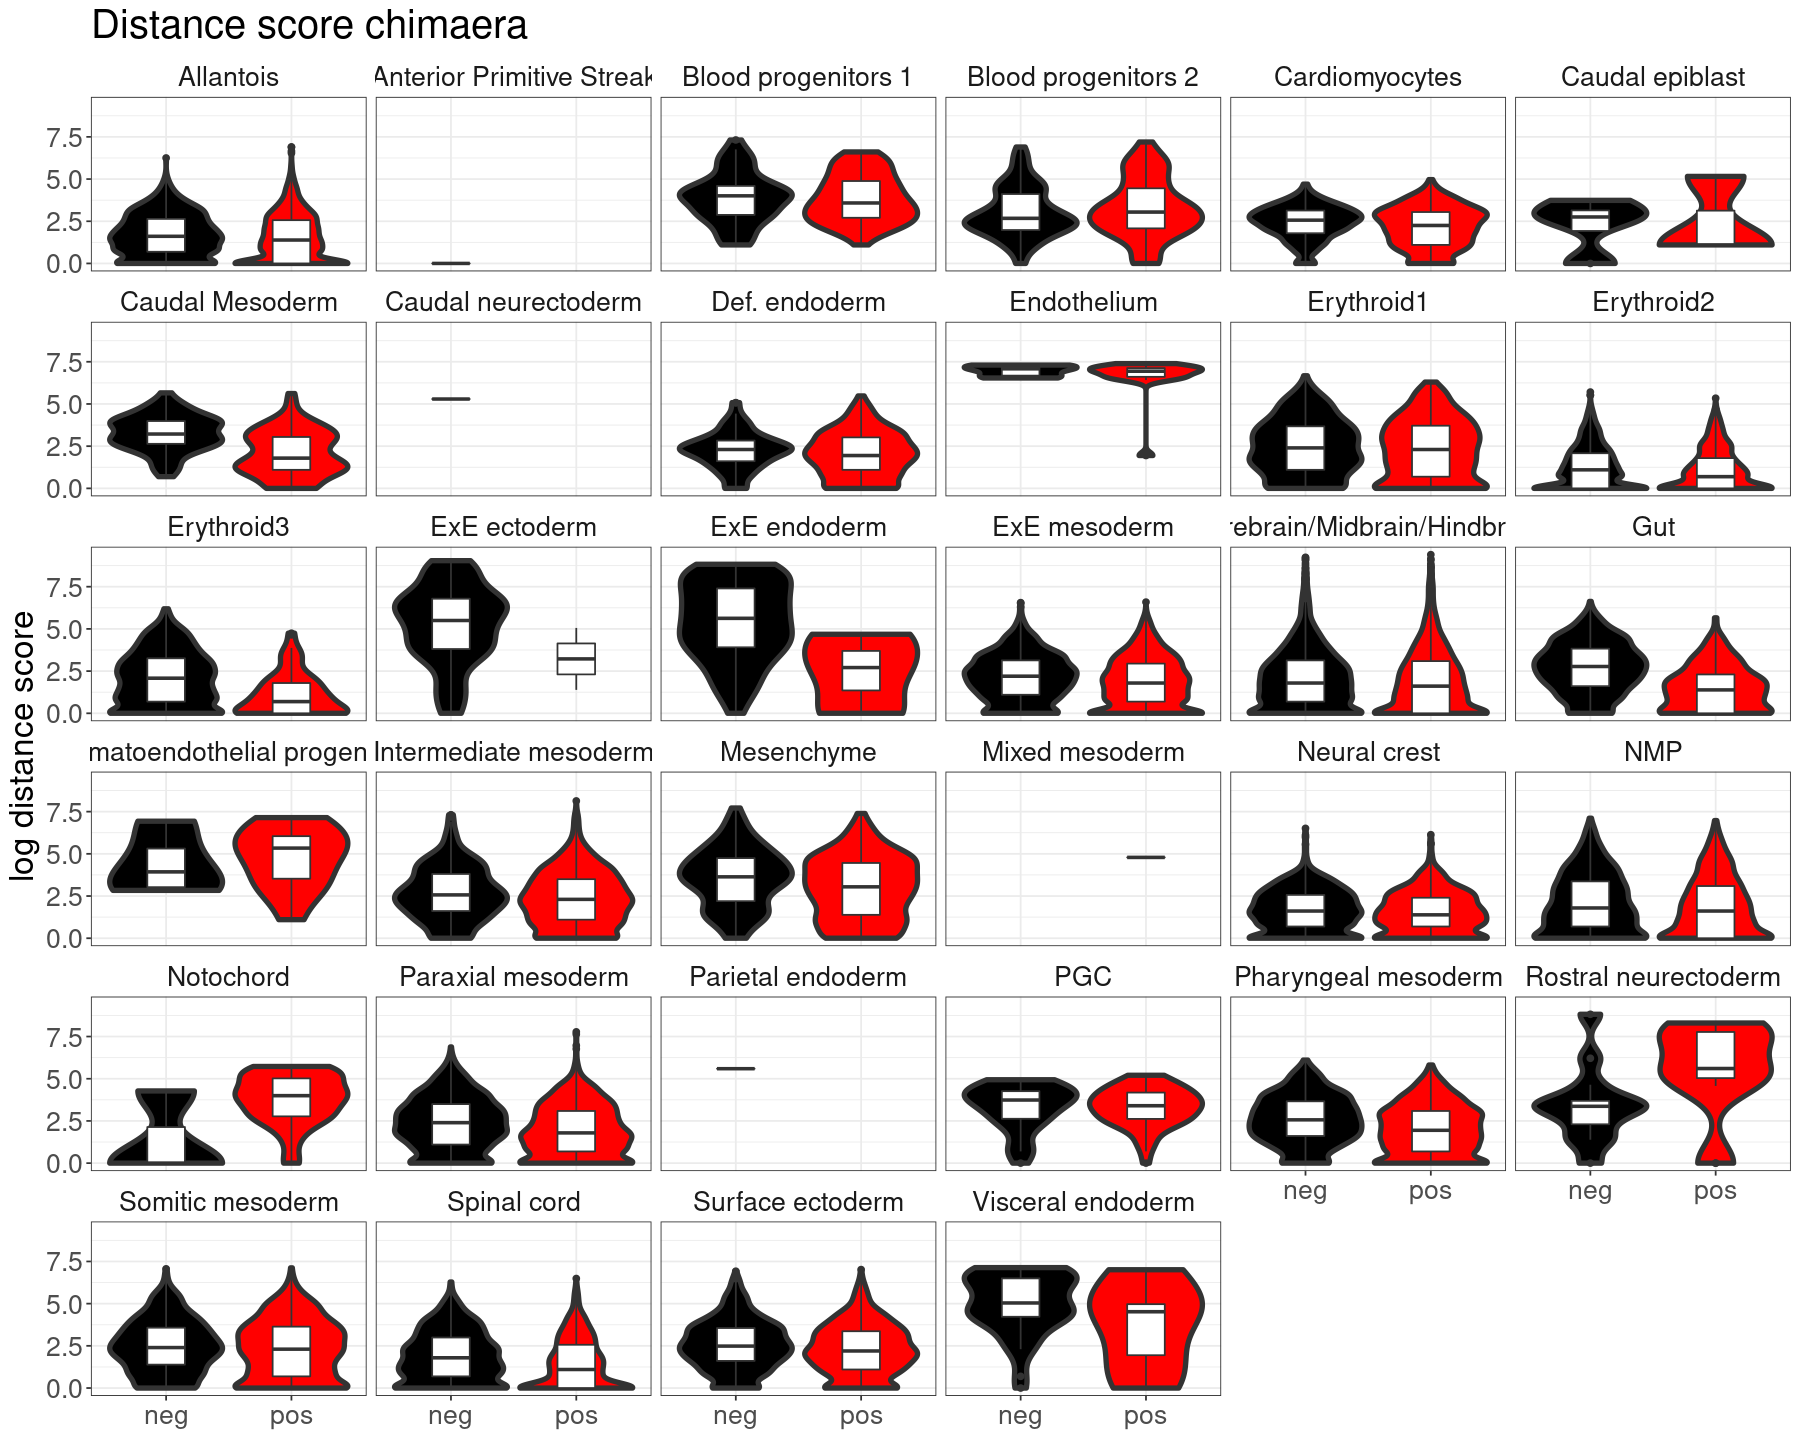

In [26]:
options(repr.plot.width=15, repr.plot.height=12)
chim = distances %>% filter(tdTom != 'NA')
ggplot(chim, aes(tdTom, log(adjacency_score_chim+1), fill=tdTom)) + 
        geom_violin(scale = 'width', size =1.5) +
        geom_boxplot(width=0.3, fill="white") +
        scale_colour_manual(values = celltype_colours, labels = celltype_labels, name = "celltype") +   
         scale_fill_manual(values = c("pos" = "red", "neg" = "black"), 
                         labels = c("pos" = "Tomato+", "neg" = "Tomato-"),
                         name = "") +
        theme_bw() +
        ggtitle('Distance score chimaera') +
        labs(y = 'log distance score') +
        theme(legend.position = "none",
            axis.title.x = element_blank(),text = element_text(size = 20)) +
        facet_wrap(~celltype) + 
        theme(strip.background = element_blank())

In [ ]:
umap = read.csv(paste0(in_folder, 'big_umap.csv'))
distances = merge(distances, umap, by='cell', all=TRUE)

In [36]:
library(viridis)
p1 = ggplot(distances, aes(umap_1, umap_2)) + 
    geom_point(aes(color=log(adjacency_score_chim+1))) + 
    theme_classic() + 
    scale_color_viridis(option = "D") + 
    theme(axis.line=element_blank(),axis.text.x=element_blank(),
          axis.text.y=element_blank(),axis.ticks=element_blank(),
          axis.title.x=element_blank(),
          axis.title.y=element_blank()) + labs(color = "log distances", text = element_text(size = 20))

png 
  2

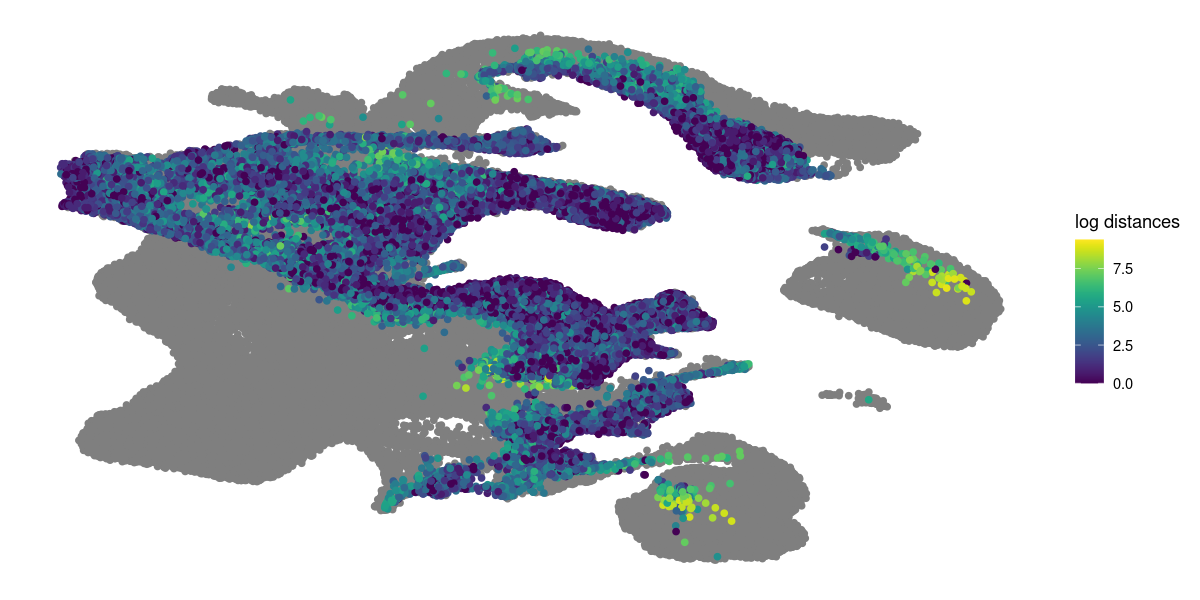

In [39]:
p1
png(paste0(plot_folder, "chim_distances_complete_umap.png"), height=800, width=800)
    p1
dev.off()